In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

In [197]:
car_dataset = pd.read_csv("C:\\Users\\JASLEEN KAUR\\Downloads\\CAR DETAILS FROM CAR DEKHO.csv" )

In [198]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [199]:
car_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [200]:
car_dataset.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [201]:
car_dataset.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [202]:
car_dataset.shape

(4340, 8)

In [203]:
print(car_dataset['fuel'].value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64


In [204]:
print(car_dataset['seller_type'].value_counts())

seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64


In [205]:
print(car_dataset['transmission'].value_counts())

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64


In [206]:
print(car_dataset['owner'].value_counts())

owner
First Owner             2832
Second Owner            1106
Third Owner              304
Fourth & Above Owner      81
Test Drive Car            17
Name: count, dtype: int64


In [207]:
car_dataset.replace({'fuel':{'Petrol':'0' ,'Diesel':'1','CNG':'2','LPG':'3','Electric':'4'}},inplace=True)

In [208]:
car_dataset.replace({'seller_type':{'Dealer':'0' ,'Individual':'1','Trustmark Dealer':'2'}},inplace=True)

In [209]:
car_dataset.replace({'transmission':{'Manual':'0' ,'Automatic':'1'}},inplace=True)

In [210]:
car_dataset.replace({'owner':{'First Owner':'0' ,'Second Owner':'1','Third Owner':'2','Fourth & Above Owner':'3','Test Drive Car':'4'}},inplace=True)

In [211]:
car_dataset.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,0,1,0,0
1,Maruti Wagon R LXI Minor,2007,135000,50000,0,1,0,0
2,Hyundai Verna 1.6 SX,2012,600000,100000,1,1,0,0
3,Datsun RediGO T Option,2017,250000,46000,0,1,0,0
4,Honda Amaze VX i-DTEC,2014,450000,141000,1,1,0,1


In [212]:
# SPLITTING AND TESTING DATA

In [213]:
X=car_dataset.drop(['name','selling_price'],axis=1)
Y=car_dataset['selling_price']

In [214]:
print(X)

      year  km_driven fuel seller_type transmission owner
0     2007      70000    0           1            0     0
1     2007      50000    0           1            0     0
2     2012     100000    1           1            0     0
3     2017      46000    0           1            0     0
4     2014     141000    1           1            0     1
...    ...        ...  ...         ...          ...   ...
4335  2014      80000    1           1            0     1
4336  2014      80000    1           1            0     1
4337  2009      83000    0           1            0     1
4338  2016      90000    1           1            0     0
4339  2016      40000    0           1            0     0

[4340 rows x 6 columns]


In [215]:
print(Y)

0        60000
1       135000
2       600000
3       250000
4       450000
         ...  
4335    409999
4336    409999
4337    110000
4338    865000
4339    225000
Name: selling_price, Length: 4340, dtype: int64


In [216]:
# Splitting the data 

In [217]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.1 ,random_state=2)

In [218]:
# Loading the linear Regressson Model

In [219]:
linear_reg = LinearRegression()

In [220]:
print(Y_train.dtypes)

int64


In [221]:
print(X_train.dtypes)

year             int64
km_driven        int64
fuel            object
seller_type     object
transmission    object
owner           object
dtype: object


In [222]:
linear_reg.fit(X_train,Y_train)

LinearRegression()

In [223]:
training_data_prediction = linear_reg.predict(X_train)

In [224]:
error_score = metrics.r2_score(Y_train ,training_data_prediction)
print("R square score " , error_score)

R square score  0.4276361285018677


In [225]:
test_data_prediction = linear_reg.predict(X_test)

In [226]:
errorto = metrics.r2_score(Y_test , test_data_prediction)
print(errorto)

0.5027999353753416


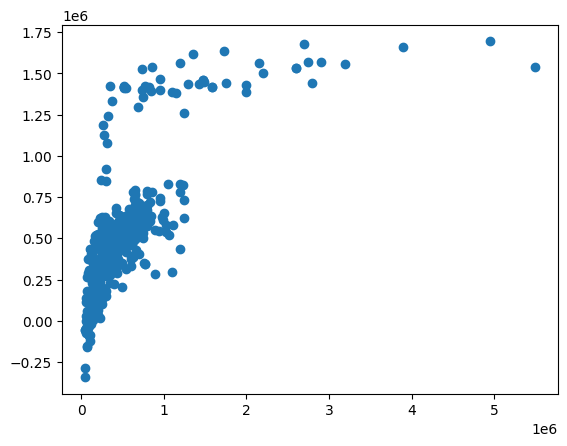

In [227]:
plt.scatter(Y_test ,test_data_prediction)

In [228]:
# Lasso Regression 

In [229]:
lasso_reg = Lasso()

In [230]:
lasso_reg.fit(X_train,Y_train)

Lasso()

In [231]:
predicted_value = lasso_reg.predict(X_train)

In [232]:
errortr = metrics.r2_score(Y_train , predicted_value)
print("error:" , errortr)

error: 0.4276361284468668


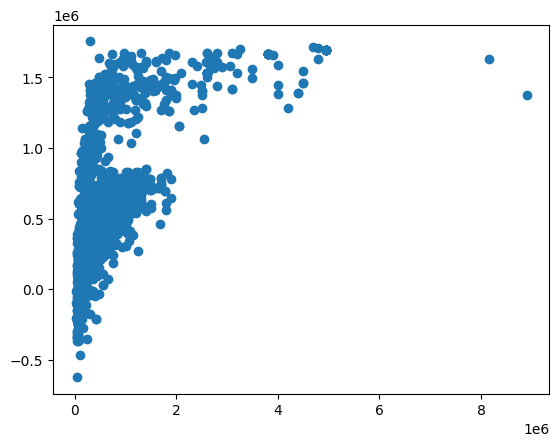

In [233]:
plt.scatter(Y_train , predicted_value)
plt.show()

In [234]:
prectiontest= lasso_reg.predict(X_test)

In [236]:
errorcal = metrics.r2_score(Y_test , prectiontest)
print("R2 error of test  value :" ,errorcal)

R2 error of test  value : 0.5027994839428185


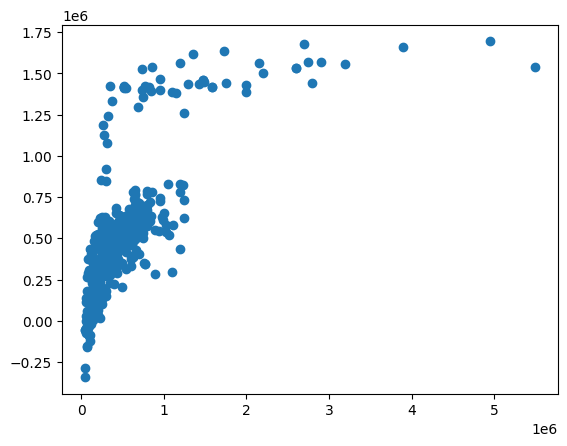

In [237]:
plt.scatter(Y_test ,prectiontest)
plt.show()